[Weather] Total expected days: 3457
[Weather] Total recorded days: 3457
[Weather] Missing Days: 0
[Water]   Total expected days: 3457
[Water]   Total recorded days: 3234
[Water]   Missing Days: 223
[Daily Flag] Pistachio tide days (sum): 88
Water data (clean) shape: (306612, 16)
Weather data (clean) shape: (3457, 17)
Merged_df (simple daily) shape: (3234, 18)
pistachio_tide
0    3146
1      88
Name: count, dtype: int64


C:\Users\Bhabh\AppData\Local\Temp\ipykernel_31900\2476094181.py:184: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  water_daily = water_df.groupby('Date').apply(daily_features).reset_index()


Merged (lagged daily features) shape: (3166, 37)
Label counts in merged (label_any):
label_any
0.0    3079
1.0      87
Name: count, dtype: int64

--- Classification Report ---
              precision    recall  f1-score   support

           0      0.952     0.998     0.975       501
           1      0.500     0.038     0.071        26

    accuracy                          0.951       527
   macro avg      0.726     0.518     0.523       527
weighted avg      0.930     0.951     0.930       527



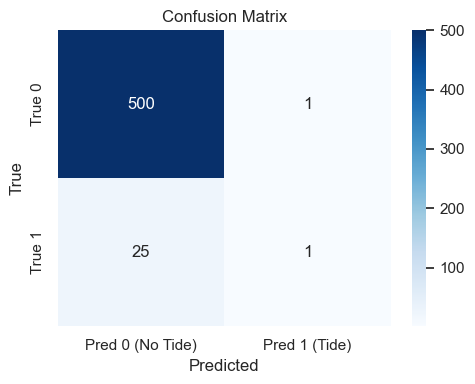

C:\Users\Bhabh\AppData\Local\Temp\ipykernel_31900\2476094181.py:266: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


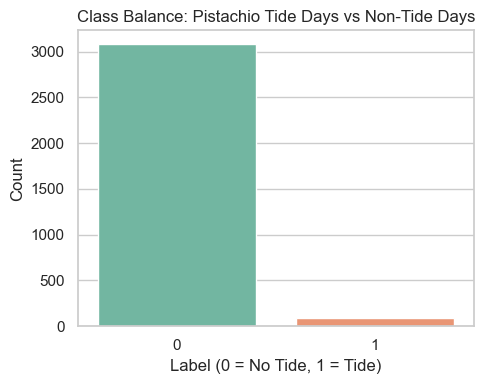

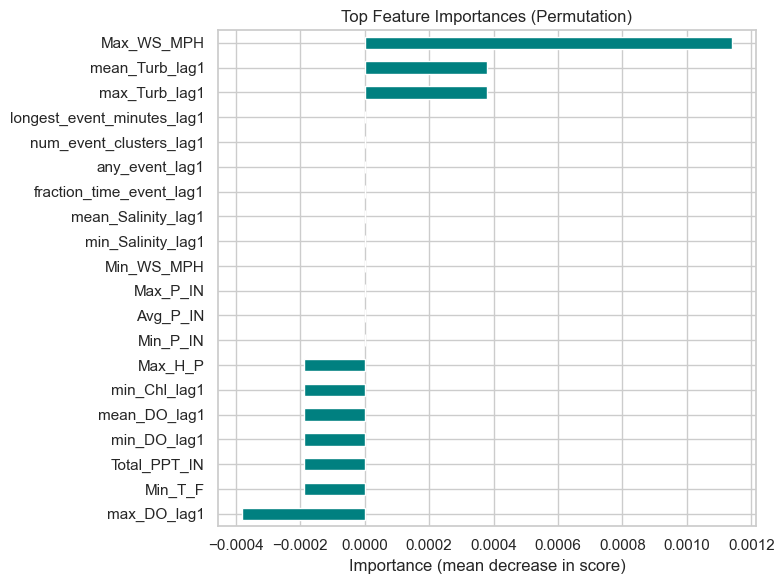


Top 20 Features by Permutation Importance:
Max_WS_MPH                    0.001139
mean_Turb_lag1                0.000380
max_Turb_lag1                 0.000380
longest_event_minutes_lag1    0.000000
num_event_clusters_lag1       0.000000
any_event_lag1                0.000000
fraction_time_event_lag1      0.000000
mean_Salinity_lag1            0.000000
min_Salinity_lag1             0.000000
Min_WS_MPH                    0.000000
Max_P_IN                      0.000000
Avg_P_IN                      0.000000
Min_P_IN                      0.000000
Max_H_P                      -0.000190
min_Chl_lag1                 -0.000190
mean_DO_lag1                 -0.000190
min_DO_lag1                  -0.000190
Total_PPT_IN                 -0.000190
Min_T_F                      -0.000190
max_DO_lag1                  -0.000380
dtype: float64


In [1]:
# ============================================================
# Pistachio tide modeling (Patapsco / Inner Harbor)
# Combines: (A) daily label from grouped water samples + weather
#           (B) interval-level daily features + 1-day lags + weather
# Author: Bhavya Prakash Gupta
# ============================================================

# ----------------------------
# 1) Imports 
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance


# ----------------------------
# 2) Load data 
# ----------------------------
weather_df = pd.read_excel(
    r"C:/Users/Bhabh/OneDrive/Desktop/Masters/Research/Weather_data_May2016-Nov2025.xlsx"
)
water_df = pd.read_csv(
    r"C:/Users/Bhabh/OneDrive/Desktop/Masters/Research/Water Data/EOTBData_Patapsco_AES_01Jan01_TO_10Nov25_Tides.csv"
)

# ----------------------------
# 3) Standardize column names
# ----------------------------
weather_df.columns = weather_df.columns.str.strip().str.replace(" ", "_")
water_df.columns   = water_df.columns.str.strip().str.replace(" ", "_")

# ----------------------------
# 4) Basic cleaning / required fields
#    (Keep your variables and thresholds)
# ----------------------------
weather_df_clean = weather_df.dropna(subset=[
    'Max_T_F','Avg_T_F','Min_T_F',
    'Max_DP_F','Avg_DP_F','Min_DP_F',
    'Max_H_P','Avg_H_P','Min_H_P',
    'Max_WS_MPH','Avg_WS_MPH','Min_WS_MPH',
    'Max_P_IN','Avg_P_IN','Min_P_IN',
    'Total_PPT_IN'
]).copy()

water_df_clean = water_df.dropna(subset=['DO_mg/L','Turb_NTU','Chl_ug/L']).copy()

# ----------------------------
# 5) Date checks 
# ----------------------------
weather_df_clean['Date'] = pd.to_datetime(weather_df_clean['Date']).dt.floor('D')
expected_dates = pd.date_range(start='2016-05-25', end='2025-11-10', freq='D')
actual_dates   = pd.Series(weather_df_clean['Date'].unique())
missing_dates  = expected_dates.difference(actual_dates)
print(f"[Weather] Total expected days: {len(expected_dates)}")
print(f"[Weather] Total recorded days: {len(actual_dates)}")
print(f"[Weather] Missing Days: {len(missing_dates)}")

water_df_clean['Sample_date'] = pd.to_datetime(water_df_clean['Sample_date'])
expected_dates = pd.date_range(start='2016-05-25', end='2025-11-10', freq='D')
actual_dates   = pd.Series(water_df_clean['Sample_date'].dt.floor('D').unique())
missing_dates  = expected_dates.difference(actual_dates)
print(f"[Water]   Total expected days: {len(expected_dates)}")
print(f"[Water]   Total recorded days: {len(actual_dates)}")
print(f"[Water]   Missing Days: {len(missing_dates)}")

# ----------------------------
# 6) (A) Label per-interval pistachio event 
#    and collapse to daily "one-day summary" label
# ----------------------------

water_df_clean['pistachio_event'] = (
    (water_df_clean['DO_mg/L'] < 2) &
    (water_df_clean['Turb_NTU']   > 5) &
    (water_df_clean['Chl_ug/L']   < 2)
).astype(int)

# Daily flag: if any sample in the day triggered an event → pistachio tide = 1
water_df_clean['Sample_date'] = pd.to_datetime(water_df_clean['Sample_date']).dt.floor('D')
daily_flag = (water_df_clean
              .groupby('Sample_date', as_index=False)['pistachio_event']
              .max()
              .rename(columns={'Sample_date':'Date','pistachio_event':'pistachio_tide'}))

print(f"[Daily Flag] Pistachio tide days (sum): {daily_flag['pistachio_tide'].sum()}")

# Merge (A): weather + daily flag (keep your variable name merged_df)
merged_df = pd.merge(weather_df_clean, daily_flag, on="Date", how='inner')
print("Water data (clean) shape:", water_df_clean.shape)
print("Weather data (clean) shape:", weather_df_clean.shape)
print("Merged_df (simple daily) shape:", merged_df.shape)
print(merged_df['pistachio_tide'].value_counts())

# ----------------------------
# 7) Plotting style
# ----------------------------
sns.set(style="whitegrid")

# ----------------------------
# 8) (B) Interval → daily features + 1-day lag + merge with weather
#    Using your second code block, with minimal fixes
# ----------------------------
# Normalize dates (consistent Timestamp type)
water_df['Sample_date'] = pd.to_datetime(water_df['Sample_date'])
water_df['Date']        = water_df['Sample_date'].dt.floor('D')
weather_df['Date']      = pd.to_datetime(weather_df['Date']).dt.floor('D')

# Define interval-level pistachio flag in full-resolution water_df
# (same thresholds as above)
water_df['pistachio_event_flag'] = (
    (water_df['DO_mg/L'] < 2) &
    (water_df['Turb_NTU']   > 5) &
    (water_df['Chl_ug/L']   < 2)
).astype(int)

# Daily feature engineering (your function, with minor safety tweaks)
def daily_features(group):
    # Basic stats
    feats = {
        'min_DO'   : group['DO_mg/L'].min(),
        'mean_DO'  : group['DO_mg/L'].mean(),
        'max_DO'   : group['DO_mg/L'].max(),
        'min_Chl'  : group['Chl_ug/L'].min(),
        'mean_Chl' : group['Chl_ug/L'].mean(),
        'max_Chl'  : group['Chl_ug/L'].max(),
        'min_Turb' : group['Turb_NTU'].min(),
        'mean_Turb': group['Turb_NTU'].mean(),
        'max_Turb' : group['Turb_NTU'].max(),
    }
    # Optional chemistry (I didn't do this)
    if 'pH' in group.columns:
        feats.update({
            'min_pH'  : group['pH'].min(),
            'mean_pH' : group['pH'].mean(),
            'max_pH'  : group['pH'].max(),
        })
    if 'Salinity_ppt' in group.columns:
        feats.update({
            'min_Salinity'  : group['Salinity_ppt'].min(),
            'mean_Salinity' : group['Salinity_ppt'].mean(),
            'max_Salinity'  : group['Salinity_ppt'].max(),
        })

    # Event metrics
    total  = len(group)
    events = int(group['pistachio_event_flag'].sum())
    feats['fraction_time_event'] = events / total if total > 0 else 0.0
    feats['any_event']           = int(events > 0)

    # Longest consecutive run (assume each row = 15 min)
    vals = group['pistachio_event_flag'].values
    longest_run = 0
    current_run = 0
    clusters    = 0
    for v in vals:
        if v == 1:
            current_run += 1
        else:
            if current_run > 0:
                longest_run = max(longest_run, current_run)
                clusters    += 1
                current_run  = 0
    if current_run > 0:
        longest_run = max(longest_run, current_run)
        clusters    += 1

    feats['num_event_clusters']   = clusters
    feats['longest_event_minutes'] = longest_run * 15  # change if your interval differs

    return pd.Series(feats)

# Build daily water feature table
water_daily = water_df.groupby('Date').apply(daily_features).reset_index()

# Define day-level label 
water_daily['label_any'] = water_daily['any_event']  # 1 if any interval met criteria

# Sort and create 1-day lags of water-derived features
water_daily = water_daily.sort_values('Date')
lag_cols = [c for c in water_daily.columns if c not in ['Date', 'label_any', 'label_2h']]
for c in lag_cols:
    water_daily[f'{c}_lag1'] = water_daily[c].shift(1)

# Keep lagged features + labels
label_col        = 'label_any'  # or 'label_2h' if you later add it
lag_feature_cols = [f'{c}_lag1' for c in lag_cols]
water_lagged     = water_daily[['Date', label_col] + lag_feature_cols]

# Merge (B): daily weather + lagged water features
merged = weather_df.merge(water_lagged, on='Date', how='inner')

# Drop first day (lag is NaN)
merged = merged.dropna(subset=lag_feature_cols)

print("Merged (lagged daily features) shape:", merged.shape)
print("Label counts in merged (label_any):")
print(merged[label_col].value_counts())



# ============================================================
# 10) Modeling — Option B: Weather + lagged water features (merged)
# ============================================================


# ============================================================
# 1. Prepare Data
# ============================================================
X = merged.drop(columns=['Date', label_col])
y = merged[label_col].astype(int)

# Impute missing values (median strategy)
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

# ============================================================
# 2. TimeSeriesSplit (use last fold for evaluation)
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)
train_idx, test_idx = list(tscv.split(X_imp))[-1]
X_train, X_test = X_imp[train_idx], X_imp[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ============================================================
# 3. Train Random Forest
# ============================================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced_subsample'  # handles imbalance better
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ============================================================
# 4. Evaluation
# ============================================================
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0 (No Tide)', 'Pred 1 (Tide)'],
            yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

# ============================================================
# 5. Class Balance Visualization
# ============================================================
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette='Set2')
plt.title('Class Balance: Pistachio Tide Days vs Non-Tide Days')
plt.xlabel('Label (0 = No Tide, 1 = Tide)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ============================================================
# 6. Permutation Feature Importance
# ============================================================
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

# Plot top 20 features
top_n = 20
plt.figure(figsize=(8,6))
importances.head(top_n).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top Feature Importances (Permutation)')
plt.xlabel('Importance (mean decrease in score)')
plt.tight_layout()
plt.show()

print("\nTop 20 Features by Permutation Importance:")
print(importances.head(top_n))